In [328]:


import xarray as xr
import fsspec
import zarr
import dask.array as da
import numpy as np
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime, timedelta
from metpy.calc import lat_lon_grid_deltas, vorticity, smooth_gaussian
from metpy.units import units
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
from scipy.spatial import cKDTree 
from collections import deque
from sklearn.metrics.pairwise import cosine_similarity
from scipy import ndimage as ndi
from scipy.ndimage import maximum_filter
from skimage.morphology import skeletonize
from skimage.morphology import medial_axis

In [298]:
allLevelsFile = '../data/sandy2012-windUV_all_levels_from_250_to_850-rechunked.zarr'
subsetLevelsFile = '../data/sandy2012-windUV_250_500_850.zarr'
sandyCoordsFile = "../data/sandy2012-coords.csv"

allLevelsDs = xr.open_zarr(allLevelsFile, consolidated=False)
subsetLevelsDs = xr.open_zarr(subsetLevelsFile, consolidated=False)
sandyCoords = pd.read_csv(sandyCoordsFile)

In [299]:
sandyCoords["datetime"] = pd.to_datetime(sandyCoords["datetime"])
sandyCoords = sandyCoords.sort_values("datetime").reset_index(drop=True)

sandyCoords["lat"] = sandyCoords["lat"].astype(float)
sandyCoords["lon"] = sandyCoords["lon"].astype(float)
sandyCoords


,datetime,lat,lon
0,2012-10-22 00:00:00,13.9,-77.8
1,2012-10-22 06:00:00,13.5,-78.2
2,2012-10-22 12:00:00,13.1,-78.6
3,2012-10-22 18:00:00,12.7,-78.7
4,2012-10-23 00:00:00,12.6,-78.4
5,2012-10-23 06:00:00,12.9,-78.1
6,2012-10-23 12:00:00,13.4,-77.9
7,2012-10-23 18:00:00,14.0,-77.6
8,2012-10-24 00:00:00,14.7,-77.3
9,2012-10-24 06:00:00,15.6,-77.1


In [300]:
def get_uv_at_level_time(ds, level, time):
    """
    Select u, v, lats, lons from an xarray Dataset at a given pressure level and time.

    Assumptions:
      - u and v are always shaped (nlat, nlon), e.g. (721, 1440)
      - latitude corresponds to axis 0
      - longitude corresponds to axis 1

    Normalization:
      - If lats are decreasing, flip lats and flip u/v along axis 0.
      - If lons are in [0, 360), convert to [-180, 180) and reorder u/v along axis 1.
    """
    sel = ds.sel(time=time, level=level)

    u = sel["u"].values
    v = sel["v"].values
    lats = sel["latitude"].values
    lons = sel["longitude"].values

    # ---- Latitude: ensure increasing (-90 -> 90) ----
    if len(lats) > 1 and lats[0] > lats[-1]:
        lats = lats[::-1]
        u = u[::-1, :]
        v = v[::-1, :]

    # ---- Longitude: ensure [-180, 180) instead of [0, 360) ----
    # Heuristic: if any lon > 180, treat as 0..360 convention.
    if len(lons) > 0 and np.nanmax(lons) > 180:
        lons_wrapped = ((lons + 180) % 360) - 180   # -> [-180, 180)
        order = np.argsort(lons_wrapped)

        lons = lons_wrapped[order]
        u = u[:, order]
        v = v[:, order]

    return u, v, lats, lons

u, v, lats, lons = get_uv_at_level_time(
    subsetLevelsDs,
    level=850,
    time="2012-10-29T00:00:00",
)

In [301]:

def interp_storm_latlon(storm_df, time):
    t = pd.to_datetime(time)

    dt = storm_df["datetime"].values

    if t.to_datetime64() < dt[0] or t.to_datetime64() > dt[-1]:
        return None

    exact = storm_df.loc[storm_df["datetime"] == t]
    if len(exact) > 0:
        return float(exact["lat"].iloc[0]), float(exact["lon"].iloc[0])

    i = np.searchsorted(dt, t.to_datetime64(), side="right")
    i0, i1 = i - 1, i

    t0 = storm_df["datetime"].iloc[i0]
    t1 = storm_df["datetime"].iloc[i1]

    frac = (t - t0) / (t1 - t0)

    lat0, lat1 = storm_df["lat"].iloc[i0], storm_df["lat"].iloc[i1]
    lon0, lon1 = storm_df["lon"].iloc[i0], storm_df["lon"].iloc[i1]

    lat = float(lat0 + frac * (lat1 - lat0))
    lon = float(lon0 + frac * (lon1 - lon0))

    return lat, lon

def plot_wind_quiver_single_uv(
    u,
    v,
    lats,
    lons,
    *,
    time=None,                          # only used for storm dot interpolation
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    title: str | None = None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
    show_quiver = True,
):
    """
    Core renderer: given u/v + lat/lon arrays for ONE time, plot quiver + coastline +
    optional storm dot at `time` (and +6h dot).
    """
    Lon, Lat = np.meshgrid(lons, lats)

    Lon_s = Lon[::stride, ::stride]
    Lat_s = Lat[::stride, ::stride]
    u_s   = u[::stride, ::stride]
    v_s   = v[::stride, ::stride]

    speed = np.sqrt(u_s**2 + v_s**2)

    if max_speed_for_black is None:
        max_speed_for_black = float(np.nanpercentile(speed, 95)) if np.isfinite(speed).any() else 1.0
        if max_speed_for_black <= 0:
            max_speed_for_black = 1.0

    if ax is None:
        fig = plt.figure(figsize=(6, 4))
        ax = plt.axes(projection=ccrs.PlateCarree())
    else:
        fig = None

    ax.set_facecolor("white")

    if extent is not None:
        lon_min, lon_max, lat_min, lat_max = extent
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    if show_quiver:
        ax.quiver(
            Lon_s, Lat_s, u_s, v_s, speed,
            transform=ccrs.PlateCarree(),
            cmap="Greys",
            clim=(0.0, max_speed_for_black),
            scale=1500,
            width=0.0012,
            pivot="middle",
        )

    # storm dots (needs time)
    if show_storm_dot and storm_df is not None and time is not None:
        pt = interp_storm_latlon(storm_df, time)
        if pt is not None:
            lat_pt, lon_pt = pt
            ax.scatter(
                [lon_pt], [lat_pt],
                transform=ccrs.PlateCarree(),
                s=storm_dot_size,
                c="red",
                edgecolors="none",
                zorder=10,
            )

            t_next = pd.to_datetime(time) + pd.Timedelta(hours=6)
            pt2 = interp_storm_latlon(storm_df, t_next)
            if pt2 is not None:
                lat2, lon2 = pt2
                ax.scatter(
                    [lon2], [lat2],
                    transform=ccrs.PlateCarree(),
                    s=storm_dot_size,
                    c="#ff9999",
                    edgecolors="none",
                    zorder=10,
                )
                ax.plot(
                    [lon_pt, lon2],
                    [lat_pt, lat2],
                    transform=ccrs.PlateCarree(),
                    color="red",
                    linewidth=1.5,
                    zorder=9,
                )

    if title is not None:
        ax.set_title(title)

    return fig, ax


def plot_wind_quiver_single_from_ds(
    ds,
    pressure_hpa: int,
    time,
    *,
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    """
    Convenience wrapper: select u/v from ds at (time, pressure_hpa), then call core UV plotter.
    """
    sel = ds.sel(level=pressure_hpa).sel(time=time)

    u = sel["u"].values
    v = sel["v"].values
    lats = sel["latitude"].values
    lons = sel["longitude"].values

    return plot_wind_quiver_single_uv(
        u,
        v,
        lats,
        lons,
        time=time,
        stride=stride,
        extent=extent,
        max_speed_for_black=max_speed_for_black,
        ax=ax,
        title=f"{pressure_hpa} hPa",
        storm_df=storm_df,
        show_storm_dot=show_storm_dot,
        storm_dot_size=storm_dot_size,
    )


def plot_wind_quiver_levels_side_by_side(
    ds,
    pressure_levels,
    time,
    *,
    stride: int = 10,
    extent=None,
    # max_speed_for_black=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    n = len(pressure_levels)

    fig = plt.figure(figsize=(5 * n, 5))
    axes = []
    
    QUIVER_MAX_SPEEDS = {
        850: 35,   # m/s — low-level inflow & storm-scale circulation
        500: 45,   # m/s — mid-level steering flow
        250: 70,   # m/s — upper-level outflow & jet stream
    }


    for i, lvl in enumerate(pressure_levels, start=1):
        ax = fig.add_subplot(1, n, i, projection=ccrs.PlateCarree())
        axes.append(ax)
        max_speed = None
        max_speed = QUIVER_MAX_SPEEDS.get(lvl, None)

        plot_wind_quiver_single_from_ds(
            ds,
            lvl,
            time,
            stride=stride,
            extent=extent,
            max_speed_for_black=max_speed,
            ax=ax,
            storm_df=storm_df,
            show_storm_dot=show_storm_dot,
            storm_dot_size=storm_dot_size,
        )

    fig.suptitle(f"Wind Quivers — {time}", y=0.98)
    fig.tight_layout(w_pad=0.2)

    return fig, axes


In [302]:
def mask_lonely_arrows(u_masked, v_masked, lats, lons, radius_km=50.0, min_neighbors=2):
    """
    Mask arrows (set to NaN) that have < min_neighbors OTHER valid arrows within radius_km.
    Uses a KD-tree in ECEF space (great-circle approx via chord distance).
    """

    u2 = np.array(u_masked, copy=True)
    v2 = np.array(v_masked, copy=True)

    # Ensure lats/lons are 2D arrays matching u/v shape
    if np.ndim(lats) == 1 and np.ndim(lons) == 1 and u2.ndim == 2:
        Lon, Lat = np.meshgrid(lons, lats)
    else:
        print('else')
        Lat = np.asarray(lats)
        Lon = np.asarray(lons)

    valid = np.isfinite(u2) & np.isfinite(v2) & np.isfinite(Lat) & np.isfinite(Lon)
    if not np.any(valid):
        print('not valid')
        return u2, v2

    # Flatten valid points
    idx = np.flatnonzero(valid.ravel())
    lat = np.deg2rad(Lat.ravel()[idx])
    lon = np.deg2rad(Lon.ravel()[idx])

    # ECEF coordinates on sphere (meters)
    R = 6_371_000.0
    x = R * np.cos(lat) * np.cos(lon)
    y = R * np.cos(lat) * np.sin(lon)
    z = R * np.sin(lat)
    pts = np.stack([x, y, z], axis=1)

    tree = cKDTree(pts)

    # Convert surface distance to chord distance for KDTree radius query
    d = radius_km * 1000.0
    chord_r = 2.0 * R * np.sin(d / (2.0 * R))

    # Count neighbors within radius (excluding itself)
    neighbors = tree.query_ball_point(pts, r=chord_r)
    counts = np.fromiter((len(n) - 1 for n in neighbors), dtype=np.int32, count=len(neighbors))

    to_drop = counts < int(min_neighbors)
    total = counts.size
    dropped = int(np.count_nonzero(to_drop))
    kept = total - dropped

    print(f"dropping {dropped} / {total} ({(dropped/total)*100:.2f}%) | "
        f"keeping {kept} / {total} ({(kept/total)*100:.2f}%)")
    if np.any(to_drop):
        drop_flat = idx[to_drop]
        np.put(u2, drop_flat, np.nan)
        np.put(v2, drop_flat, np.nan)


    return u2, v2


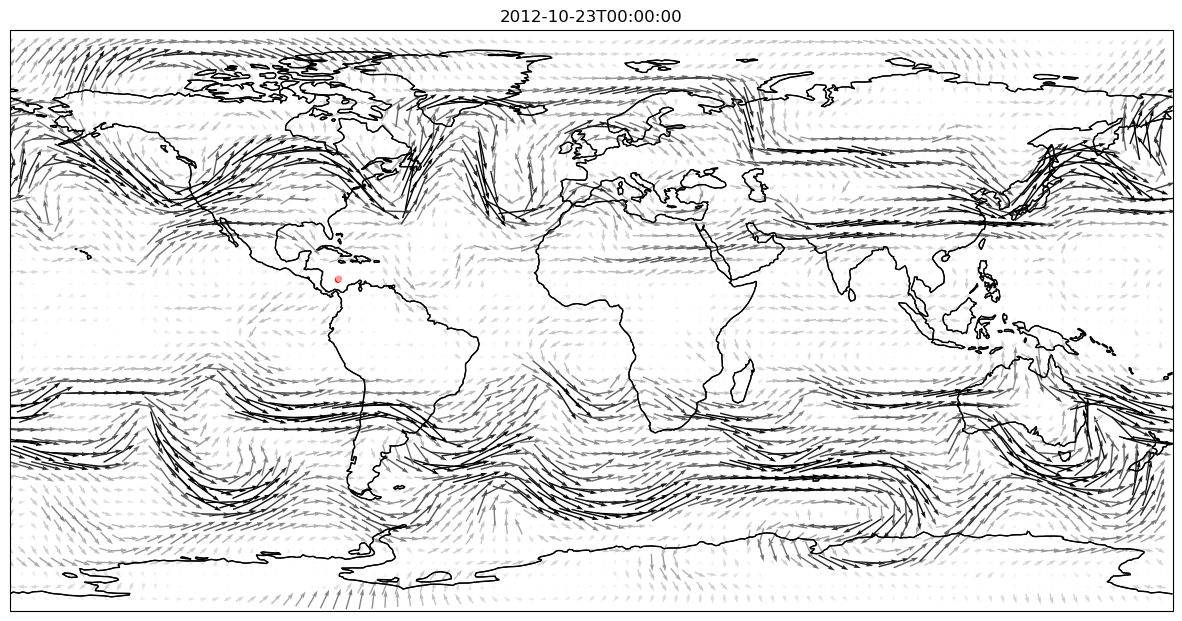

In [303]:
timeStr = "2012-10-23T00:00:00"
level = 250

u, v, lats, lons = get_uv_at_level_time(
    subsetLevelsDs,
    level=level,
    time=timeStr,
)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u, v, lats, lons,
    time=timeStr,
    stride=15,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()


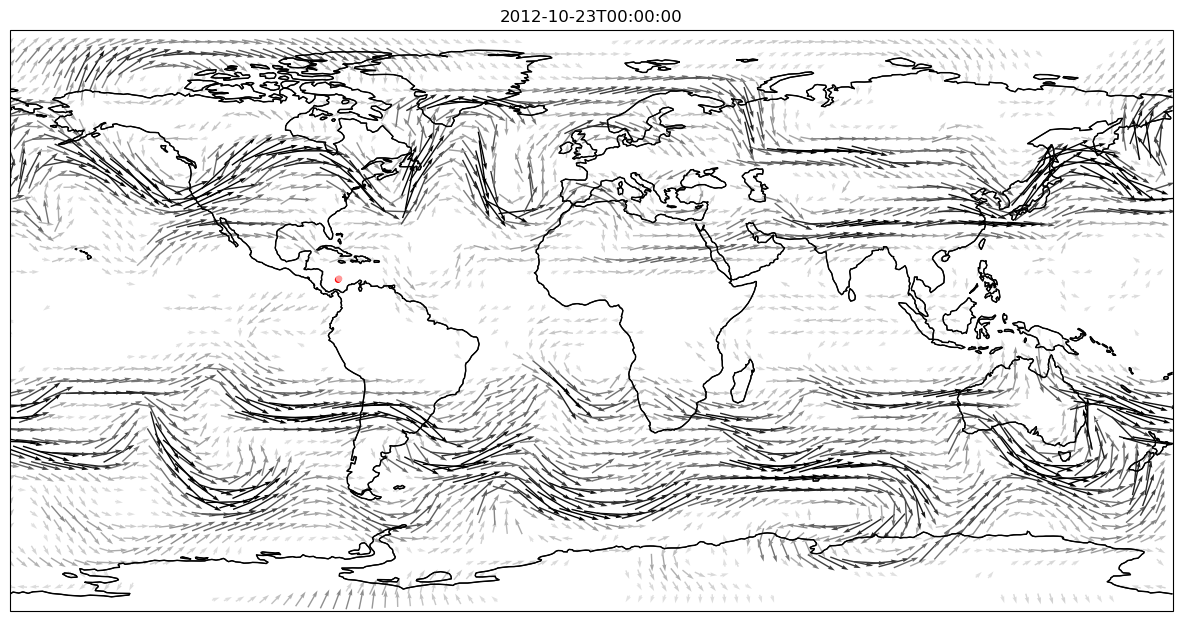

In [304]:
speed = np.hypot(u, v)          # sqrt(u**2 + v**2)
mask = speed < 10.0             # True where “moves less than 10 m/s”

u_masked = np.where(mask, np.nan, u)
v_masked = np.where(mask, np.nan, v)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u_masked, v_masked, lats, lons,
    time=timeStr,
    stride=15,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()


dropping 168561 / 756171 (22.29%) | keeping 587610 / 756171 (77.71%)


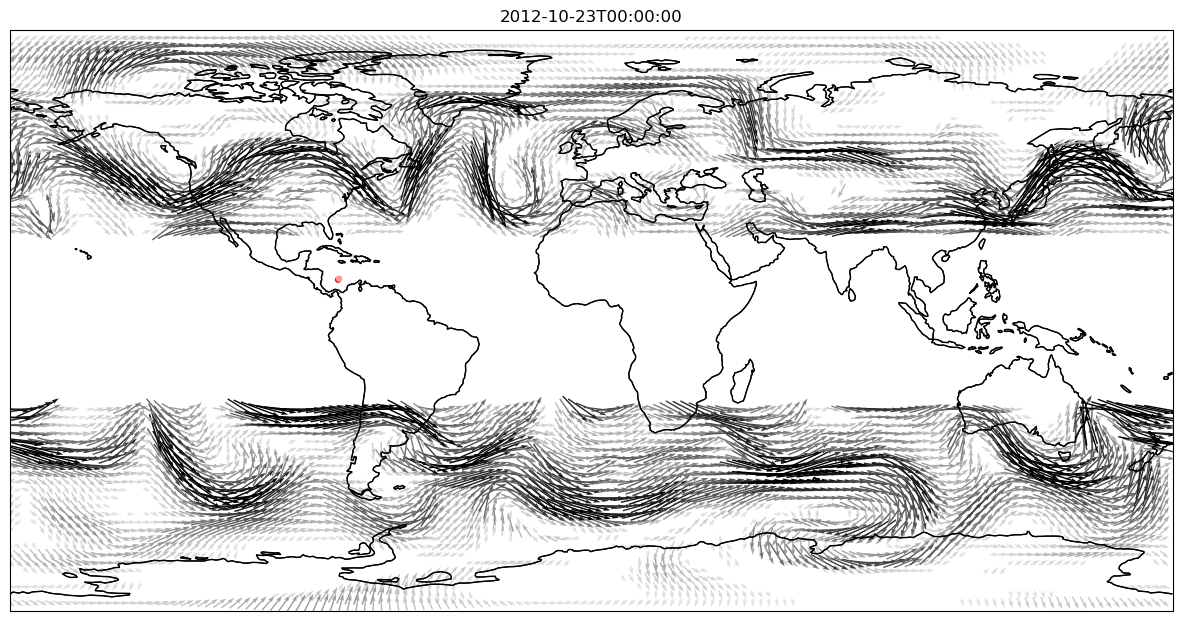

In [305]:
u_masked2, v_masked2 = mask_lonely_arrows(u_masked, v_masked, lats, lons, radius_km=50, min_neighbors=10)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u_masked2, v_masked2, lats, lons,
    time=timeStr,
    stride=10,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()

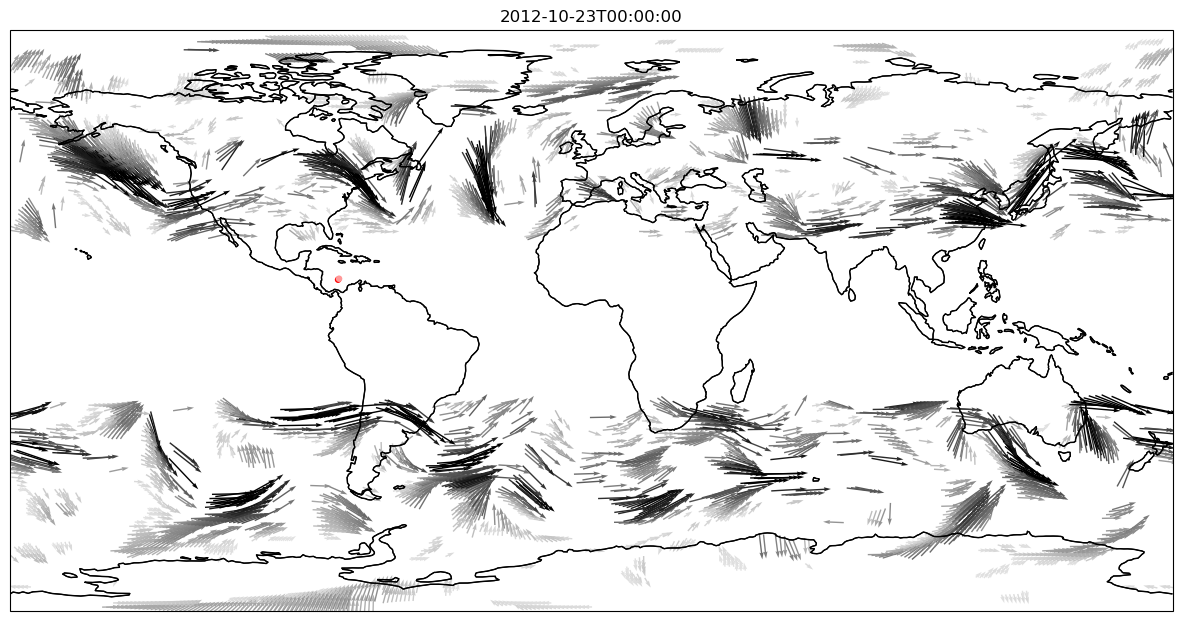

In [306]:
def step_direction_deg(u, v, lats, lons, step_deg=0.25, wrap_lon=True):
    u = np.asarray(u, float)
    v = np.asarray(v, float)

    if np.ndim(lats) == 1 and np.ndim(lons) == 1:
        Lon, Lat = np.meshgrid(np.asarray(lons, float), np.asarray(lats, float))
    else:
        Lat = np.asarray(lats, float)
        Lon = np.asarray(lons, float)

    valid = np.isfinite(u) & np.isfinite(v) & np.isfinite(Lat) & np.isfinite(Lon)

    # normalize direction
    mag = np.hypot(u, v)
    dx = np.zeros_like(u); dy = np.zeros_like(v)
    ok = valid & (mag > 0)
    dx[ok] = u[ok] / mag[ok]
    dy[ok] = v[ok] / mag[ok]

    end_lat = np.full_like(Lat, np.nan)
    end_lon = np.full_like(Lon, np.nan)
    end_lat[ok] = Lat[ok] + step_deg * dy[ok]
    end_lon[ok] = Lon[ok] + step_deg * dx[ok]

    if wrap_lon:
        end_lon = (end_lon + 180.0) % 360.0 - 180.0

    return Lat, Lon, end_lat, end_lon

def lon_diff_deg(a, b):
    return np.abs(((a - b + 180.0) % 360.0) - 180.0)

def mask_by_adjacent_similarity_count(
    end_lat,
    end_lon,
    u,
    v,
    lat_thresh=1.0,
    lon_thresh=1.0,
    K=2,
):
    """
    Compute 4-neighbor similarity counts on (end_lat,end_lon), keep cells with count>=K,
    and apply that mask to end_lat/end_lon and u/v.

    Returns:
      end_lat2, end_lon2, u2, v2, neighbor_ct, keep
    """
    end_lat = np.asarray(end_lat, float)
    end_lon = np.asarray(end_lon, float)
    u = np.asarray(u, float)
    v = np.asarray(v, float)

    H, W = end_lat.shape
    valid = np.isfinite(end_lat) & np.isfinite(end_lon) & np.isfinite(u) & np.isfinite(v)

    neighbor_ct = np.zeros((H, W), dtype=np.int16)

    # Horizontal pairs (i,j) <-> (i,j+1)
    ok = valid[:, :-1] & valid[:, 1:]
    close_h = ok & (np.abs(end_lat[:, :-1] - end_lat[:, 1:]) <= lat_thresh) & (
        lon_diff_deg(end_lon[:, :-1], end_lon[:, 1:]) <= lon_thresh
    )
    neighbor_ct[:, :-1] += close_h.astype(np.int16)
    neighbor_ct[:,  1:] += close_h.astype(np.int16)

    # Vertical pairs (i,j) <-> (i+1,j)
    ok = valid[:-1, :] & valid[1:, :]
    close_v = ok & (np.abs(end_lat[:-1, :] - end_lat[1:, :]) <= lat_thresh) & (
        lon_diff_deg(end_lon[:-1, :], end_lon[1:, :]) <= lon_thresh
    )
    neighbor_ct[:-1, :] += close_v.astype(np.int16)
    neighbor_ct[ 1:, :] += close_v.astype(np.int16)

    keep = valid & (neighbor_ct >= int(K))

    end_lat2 = np.where(keep, end_lat, np.nan)
    end_lon2 = np.where(keep, end_lon, np.nan)
    u2 = np.where(keep, u, np.nan)
    v2 = np.where(keep, v, np.nan)

    return end_lat2, end_lon2, u2, v2, neighbor_ct, keep

start_lat, start_lon, end_lat, end_lon = step_direction_deg(u_masked2, v_masked2, lats, lons)

end_lat2, end_lon2, u3, v3, neighbor_ct, keep = mask_by_adjacent_similarity_count(
    end_lat, end_lon,
    u_masked2, v_masked2,
    lat_thresh=0.25, lon_thresh=0.25,
    K=4
)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u3, v3, lats, lons,
    time=timeStr,
    stride=5,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()

In [307]:
def lon_diff_deg(a, b):
    return np.abs(((a - b + 180.0) % 360.0) - 180.0)

def build_components_from_endpoints(end_lat, end_lon, keep, lat_thresh, lon_thresh):
    """
    Returns:
      labels: int32 array same shape, -1 for not-kept, else component id [0..C-1]
      ncomp: number of components
    """
    end_lat = np.asarray(end_lat, float)
    end_lon = np.asarray(end_lon, float)
    keep = np.asarray(keep, bool)

    H, W = end_lat.shape
    labels = np.full((H, W), -1, dtype=np.int32)

    def close(i1, j1, i2, j2):
        # assumes both cells are keep==True
        if not (np.isfinite(end_lat[i1, j1]) and np.isfinite(end_lon[i1, j1]) and
                np.isfinite(end_lat[i2, j2]) and np.isfinite(end_lon[i2, j2])):
            return False
        return (abs(end_lat[i1, j1] - end_lat[i2, j2]) <= lat_thresh and
                lon_diff_deg(end_lon[i1, j1], end_lon[i2, j2]) <= lon_thresh)

    cid = 0
    for i in range(H):
        for j in range(W):
            if not keep[i, j] or labels[i, j] != -1:
                continue

            # BFS flood fill
            q = deque([(i, j)])
            labels[i, j] = cid

            while q:
                x, y = q.popleft()
                for nx, ny in ((x-1,y), (x+1,y), (x,y-1), (x,y+1)):
                    if nx < 0 or nx >= H or ny < 0 or ny >= W:
                        continue
                    if not keep[nx, ny] or labels[nx, ny] != -1:
                        continue
                    if close(x, y, nx, ny):
                        labels[nx, ny] = cid
                        q.append((nx, ny))

            cid += 1

    return labels, cid

def merged_lines_from_components(
    start_lat, start_lon, end_lat, end_lon, keep,
    lat_thresh=0.25, lon_thresh=0.25,
    min_cells=1
):
    """
    Returns:
      lines: list[(slon, slat, elon, elat, n_cells)] for components with n_cells>=min_cells
      labels_full: int grid, -1 for not-kept, else component id in [0..ncomp-1]
      labels_filtered: int grid, -1 except components that pass min_cells, remapped to [0..len(lines)-1]
      cid_map: dict old_cid -> new_cid (only for kept components)
    """
    start_lat = np.asarray(start_lat, float)
    start_lon = np.asarray(start_lon, float)
    end_lat   = np.asarray(end_lat, float)
    end_lon   = np.asarray(end_lon, float)
    keep      = np.asarray(keep, bool)

    labels_full, ncomp = build_components_from_endpoints(end_lat, end_lon, keep, lat_thresh, lon_thresh)

    # collect kept component ids + lines
    kept_cids = []
    lines = []

    for cid in range(ncomp):
        idx = np.where(labels_full == cid)
        n = idx[0].size
        if n < min_cells:
            continue

        slat = np.nanmean(start_lat[idx])
        slon = np.nanmean(start_lon[idx])
        elat = np.nanmean(end_lat[idx])
        elon = np.nanmean(end_lon[idx])

        kept_cids.append(cid)
        lines.append((slon, slat, elon, elat, n))

    # build filtered/remapped label grid
    labels_filtered = np.full_like(labels_full, -1, dtype=np.int32)
    cid_map = {cid: k for k, cid in enumerate(kept_cids)}

    for old_cid, new_cid in cid_map.items():
        labels_filtered[labels_full == old_cid] = new_cid

    return lines, labels_full, labels_filtered, cid_map

lines, labels_full, labels_filt, cid_map = merged_lines_from_components(
    start_lat, start_lon, end_lat, end_lon, keep,
    lat_thresh=0.25, lon_thresh=0.25,
    min_cells=100
)

labels_masked = np.ma.masked_where(labels_filt < 0, labels_filt)



In [308]:
print(len(lines))
[i[4] for i in lines]

176


[5359,
 1036,
 243,
 223,
 130,
 167,
 101,
 291,
 2610,
 133,
 422,
 401,
 106,
 2884,
 4409,
 225,
 124,
 109,
 192,
 254,
 682,
 299,
 108,
 1501,
 174,
 171,
 138,
 664,
 1033,
 160,
 530,
 1061,
 209,
 168,
 435,
 538,
 2603,
 378,
 186,
 108,
 223,
 1676,
 284,
 296,
 171,
 1072,
 1884,
 157,
 794,
 235,
 268,
 142,
 118,
 295,
 309,
 119,
 234,
 1047,
 202,
 246,
 379,
 284,
 126,
 593,
 296,
 172,
 152,
 137,
 174,
 314,
 288,
 110,
 165,
 1246,
 685,
 143,
 106,
 158,
 161,
 191,
 102,
 114,
 208,
 294,
 411,
 145,
 184,
 595,
 117,
 128,
 409,
 291,
 122,
 194,
 966,
 809,
 110,
 196,
 225,
 723,
 942,
 142,
 103,
 270,
 112,
 1777,
 194,
 259,
 173,
 162,
 130,
 490,
 189,
 1431,
 126,
 242,
 348,
 332,
 619,
 161,
 763,
 180,
 129,
 496,
 626,
 127,
 179,
 1039,
 5724,
 182,
 183,
 216,
 534,
 102,
 142,
 121,
 189,
 294,
 375,
 115,
 181,
 106,
 1886,
 299,
 431,
 203,
 108,
 352,
 101,
 1097,
 326,
 755,
 1986,
 193,
 1028,
 116,
 342,
 273,
 703,
 212,
 198,
 188,
 184,


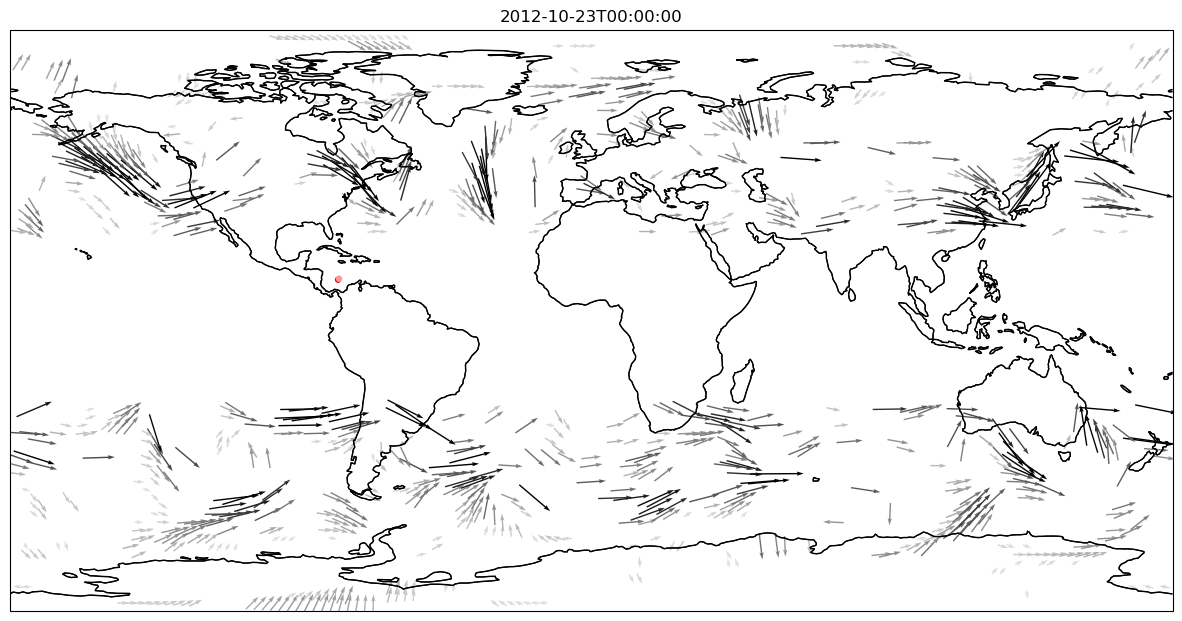

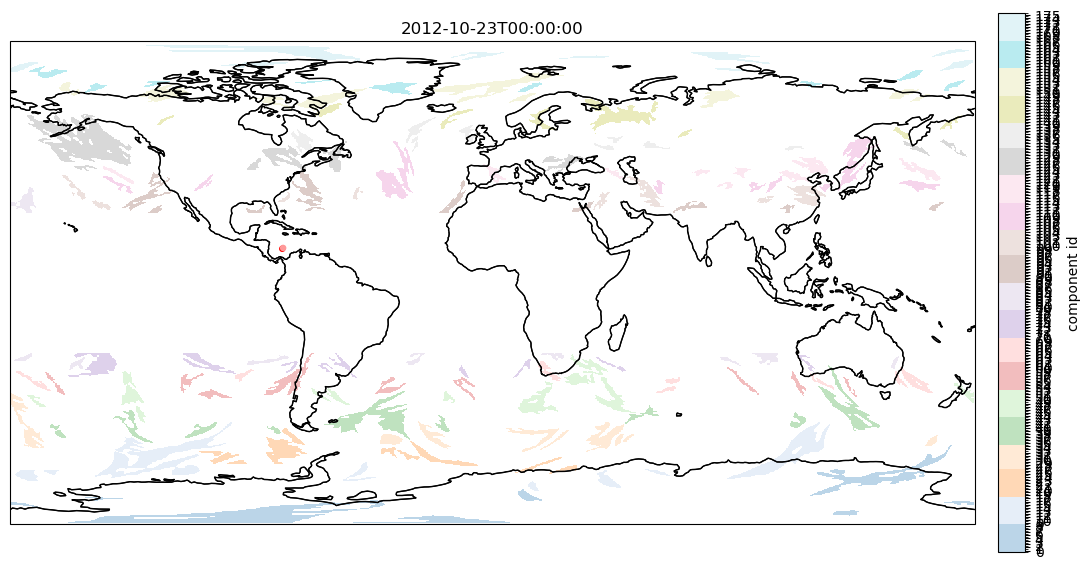

In [309]:
# --- build 2D Lon/Lat for label plotting (works whether lats/lons are 1D or 2D)
if np.ndim(lats) == 1 and np.ndim(lons) == 1:
    Lon2, Lat2 = np.meshgrid(np.asarray(lons, float), np.asarray(lats, float))
else:
    Lat2 = np.asarray(lats, float)
    Lon2 = np.asarray(lons, float)
    
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

# --- base wind (your existing plot)
plot_wind_quiver_single_uv(
    u3, v3, lats, lons,
    time=timeStr,
    stride=10,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
    show_quiver=True,
)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

# --- base wind (your existing plot)
plot_wind_quiver_single_uv(
    u3, v3, lats, lons,
    time=timeStr,
    stride=1,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
    show_quiver=False,
)

# # --- draw component labels as a translucent raster
# # (pcolormesh expects corner grids; this still works fine for visualization)
# pm = ax.pcolormesh(
#     Lon2, Lat2, labels_masked,
#     transform=ccrs.PlateCarree(),
#     alpha=0.30,
#     shading="auto",
# )

# # optional: show a colorbar for component ids
# plt.colorbar(pm, ax=ax, shrink=0.7, pad=0.02, label="component id")

# # --- draw merged lines (one per component)
# # lines is: (slon, slat, elon, elat, n_cells)
# for slon, slat, elon, elat, n in lines:
#     ax.annotate(
#         "",  # no text, just an arrow
#         xy=(elon, elat),
#         xytext=(slon, slat),
#         xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
#         textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
#         arrowprops=dict(arrowstyle="-|>", linewidth=2, mutation_scale=12)
#     )

#     # optional: annotate blob size near midpoint
#     mx = 0.5 * (slon + elon)
#     my = 0.5 * (slat + elat)
#     ax.text(mx, my, f"{n}", transform=ccrs.PlateCarree(), fontsize=8)
    
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

N = len(lines)
cmap = plt.get_cmap("tab20", N)  # discrete N colors (if N>20 it repeats-ish)
norm = mcolors.BoundaryNorm(np.arange(-0.5, N + 0.5, 1), cmap.N)

pm = ax.pcolormesh(Lon2, Lat2, labels_masked, transform=ccrs.PlateCarree(),
                   alpha=0.30, shading="auto", cmap=cmap, norm=norm)

cb = plt.colorbar(pm, ax=ax, shrink=0.7, pad=0.02)
cb.set_ticks(np.arange(N))
cb.set_label("component id")


plt.show()


587610
342348


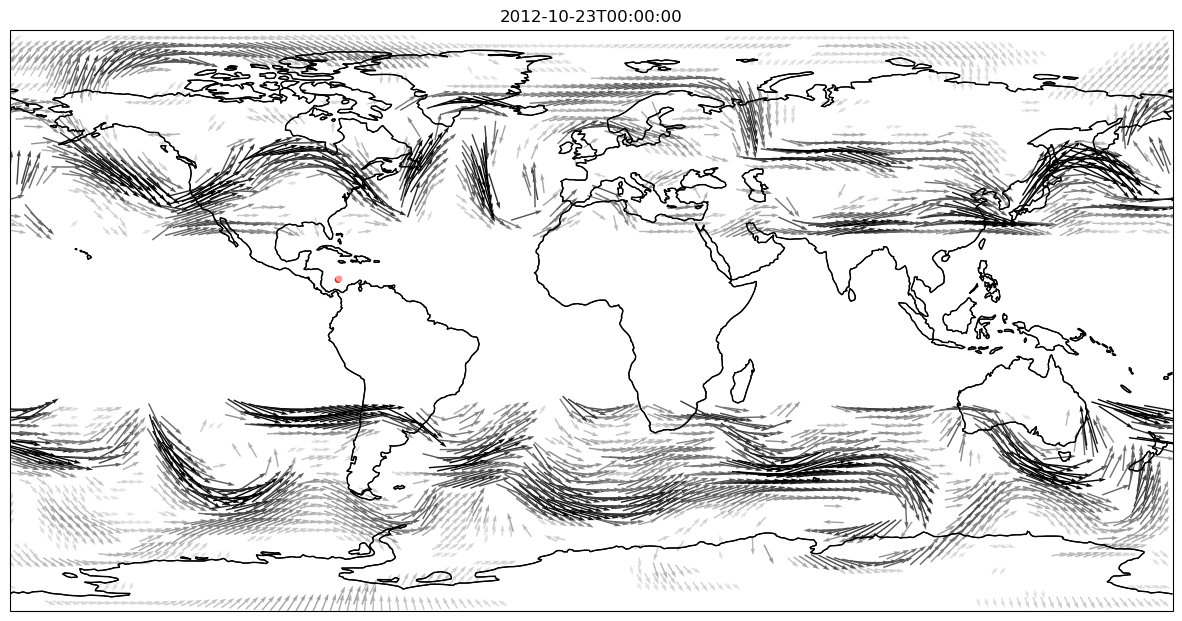

In [310]:
def neighbor_direction_filter(u, v, *, min_neighbors=2, threshold=0.7, eps=1e-8, lon_wrap=True):
    """
    4-neighbor (N,S,E,W) direction agreement using cosine similarity, mapped to [0,1] as (cos+1)/2.
    Ignores NaN neighbors (doesn't count them). Masks center if too few valid neighbors or score<threshold.
    """
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)

    speed = np.hypot(u, v)
    valid_c = np.isfinite(u) & np.isfinite(v) & (speed > eps)

    def shift_lat(arr, d):
        out = np.roll(arr, shift=d, axis=0)
        if d > 0:
            out[:d, :] = np.nan
        elif d < 0:
            out[d:, :] = np.nan
        return out

    def shift_lon(arr, d):
        out = np.roll(arr, shift=d, axis=1)
        if not lon_wrap:
            if d > 0:
                out[:, :d] = np.nan
            elif d < 0:
                out[:, d:] = np.nan
        return out

    # Neighbors
    uN, vN = shift_lat(u, -1), shift_lat(v, -1)
    uS, vS = shift_lat(u, +1), shift_lat(v, +1)
    uE, vE = shift_lon(u, +1), shift_lon(v, +1)
    uW, vW = shift_lon(u, -1), shift_lon(v, -1)

    def valid_nb(uu, vv):
        return np.isfinite(uu) & np.isfinite(vv) & (np.hypot(uu, vv) > eps)

    okN, okS, okE, okW = valid_nb(uN, vN), valid_nb(uS, vS), valid_nb(uE, vE), valid_nb(uW, vW)

    # Unit vectors (set invalid to 0 so math is safe; masks ensure they don't count)
    def unit(uu, vv):
        sp = np.hypot(uu, vv)
        uu_hat = np.divide(uu, sp, out=np.zeros_like(uu), where=(sp > eps) & np.isfinite(sp))
        vv_hat = np.divide(vv, sp, out=np.zeros_like(vv), where=(sp > eps) & np.isfinite(sp))
        return uu_hat, vv_hat

    uc_hat, vc_hat = unit(u, v)
    uN_hat, vN_hat = unit(uN, vN)
    uS_hat, vS_hat = unit(uS, vS)
    uE_hat, vE_hat = unit(uE, vE)
    uW_hat, vW_hat = unit(uW, vW)

    def cos01(u1, v1, u2, v2, nb_ok):
        cos = u1 * u2 + v1 * v2                    # in [-1, 1] ideally
        s01 = 0.5 * (cos + 1.0)                    # map to [0, 1]
        s01 = np.where(valid_c & nb_ok, s01, np.nan)
        return s01

    sN = cos01(uc_hat, vc_hat, uN_hat, vN_hat, okN)
    sS = cos01(uc_hat, vc_hat, uS_hat, vS_hat, okS)
    sE = cos01(uc_hat, vc_hat, uE_hat, vE_hat, okE)
    sW = cos01(uc_hat, vc_hat, uW_hat, vW_hat, okW)

    sims = np.stack([sN, sS, sE, sW], axis=0)      # (4, lat, lon)
    k = np.sum(np.isfinite(sims), axis=0)
    # score = np.nanmean(sims, axis=0)
    score = np.nan_to_num(sims, nan=0.0).sum(axis=0) / 4.0


    keep = valid_c & (k >= min_neighbors) & (score >= threshold)
    u2 = np.where(keep, u, np.nan)
    v2 = np.where(keep, v, np.nan)

    return u2, v2, score, k

u_similar, v_similar, score, k = neighbor_direction_filter(u_masked2, v_masked2, min_neighbors=4, threshold=0.9999, eps=1e-8, lon_wrap=True)
print(np.count_nonzero(np.isfinite(u_masked2)))
print(np.count_nonzero(np.isfinite(u_similar)))

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u_similar, v_similar, lats, lons,
    time=timeStr,
    stride=10,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()


num clusters: 17 largest: 85761


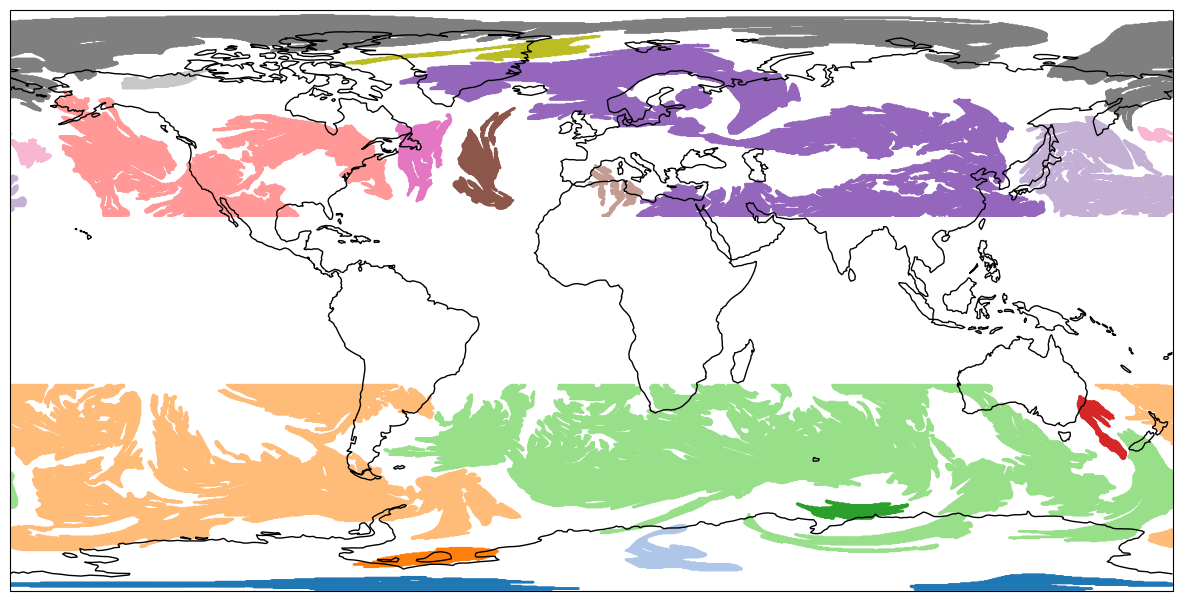

In [311]:
def cluster_uv_connected(u, v, *, sim_thresh=0.95, eps=1e-8, lon_wrap=True, min_size=1):
    """
    Clusters valid wind vectors into connected groups where adjacent vectors have cosine similarity >= sim_thresh.
    Returns:
      labels: int32 array same shape, -1 for invalid, else cluster id [0..K-1]
      sizes: 1D array of cluster sizes (after min_size filtering)
    """
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    H, W = u.shape

    speed = np.hypot(u, v)
    valid = np.isfinite(u) & np.isfinite(v) & (speed > eps)

    # Unit vectors (safe for invalid cells)
    uh = np.divide(u, speed, out=np.zeros_like(u), where=valid)
    vh = np.divide(v, speed, out=np.zeros_like(v), where=valid)

    # --- Build adjacency (right and down edges) ---
    # Right neighbor (E)
    uhE = np.roll(uh, -1, axis=1)
    vhE = np.roll(vh, -1, axis=1)
    validE = np.roll(valid, -1, axis=1)
    cosE = uh * uhE + vh * vhE
    edgeE = valid & validE & (cosE >= sim_thresh)
    if not lon_wrap:
        edgeE[:, -1] = False  # last col has no E neighbor

    # Down neighbor (S)
    uhS = np.roll(uh, -1, axis=0)
    vhS = np.roll(vh, -1, axis=0)
    validS = np.roll(valid, -1, axis=0)
    cosS = uh * uhS + vh * vhS
    edgeS = valid & validS & (cosS >= sim_thresh)
    edgeS[-1, :] = False  # last row has no S neighbor

    # --- Union-Find over flattened indices ---
    N = H * W
    parent = np.arange(N, dtype=np.int32)
    rank = np.zeros(N, dtype=np.int8)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra = find(a); rb = find(b)
        if ra == rb: 
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    # Union E edges
    ii, jj = np.where(edgeE)
    a = ii * W + jj
    b = ii * W + ((jj + 1) % W if lon_wrap else (jj + 1))
    for x, y in zip(a, b):
        union(int(x), int(y))

    # Union S edges
    ii, jj = np.where(edgeS)
    a = ii * W + jj
    b = (ii + 1) * W + jj
    for x, y in zip(a, b):
        union(int(x), int(y))

    # --- Assign component labels ---
    labels = np.full((H, W), -1, dtype=np.int32)
    idx_valid = np.flatnonzero(valid)

    # Find root for each valid node
    roots = np.array([find(int(i)) for i in idx_valid], dtype=np.int32)

    # Map roots -> compact ids
    uniq, inv = np.unique(roots, return_inverse=True)
    comp_ids = inv.astype(np.int32)

    # Sizes
    sizes = np.bincount(comp_ids, minlength=len(uniq))

    # Optionally drop small clusters
    if min_size > 1:
        keep_comp = sizes >= min_size
        remap = np.full(len(uniq), -1, dtype=np.int32)
        remap[keep_comp] = np.arange(np.count_nonzero(keep_comp), dtype=np.int32)
        comp_ids2 = remap[comp_ids]
        ok = comp_ids2 >= 0
        labels.flat[idx_valid[ok]] = comp_ids2[ok]
        sizes = sizes[keep_comp]
    else:
        labels.flat[idx_valid] = comp_ids

    return labels, sizes

labels, sizes = cluster_uv_connected(
    u_similar, v_similar,
    sim_thresh=0.9,   # try 0.95–0.995 depending how strict you want
    lon_wrap=True,
    min_size=1000        # drop tiny specks
)
print("num clusters:", len(sizes), "largest:", sizes.max() if len(sizes) else None)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

# build Lon/Lat grids (assuming lats, lons are 1D)
Lon, Lat = np.meshgrid(lons, lats)

stride = 1  # match your plot_wind_quiver_single_uv stride

# subsample everything the same way
uu = u_similar[::stride, ::stride]
vv = v_similar[::stride, ::stride]
ll = labels[::stride, ::stride]
Lo = Lon[::stride, ::stride]
La = Lat[::stride, ::stride]

# only plot where we have a valid vector AND a cluster label
mask = np.isfinite(uu) & np.isfinite(vv) & (ll >= 0)

# map cluster ids -> colors (tab20 repeats after 20; that's fine for “clear distinct”)
cmap = plt.get_cmap("tab20")
# If you might have more than 20 clusters, this still works (wraps around)
colors = cmap((ll[mask] % cmap.N).astype(int))

# quiver with per-arrow RGBA colors
ax.quiver(
    Lo[mask], La[mask],
    uu[mask], vv[mask],
    color=colors,
    transform=ccrs.PlateCarree(),
    pivot="mid",
    scale=None,          # let matplotlib choose; set if you prefer fixed scaling
    width=0.0025         # tweak thickness
)

plt.show()



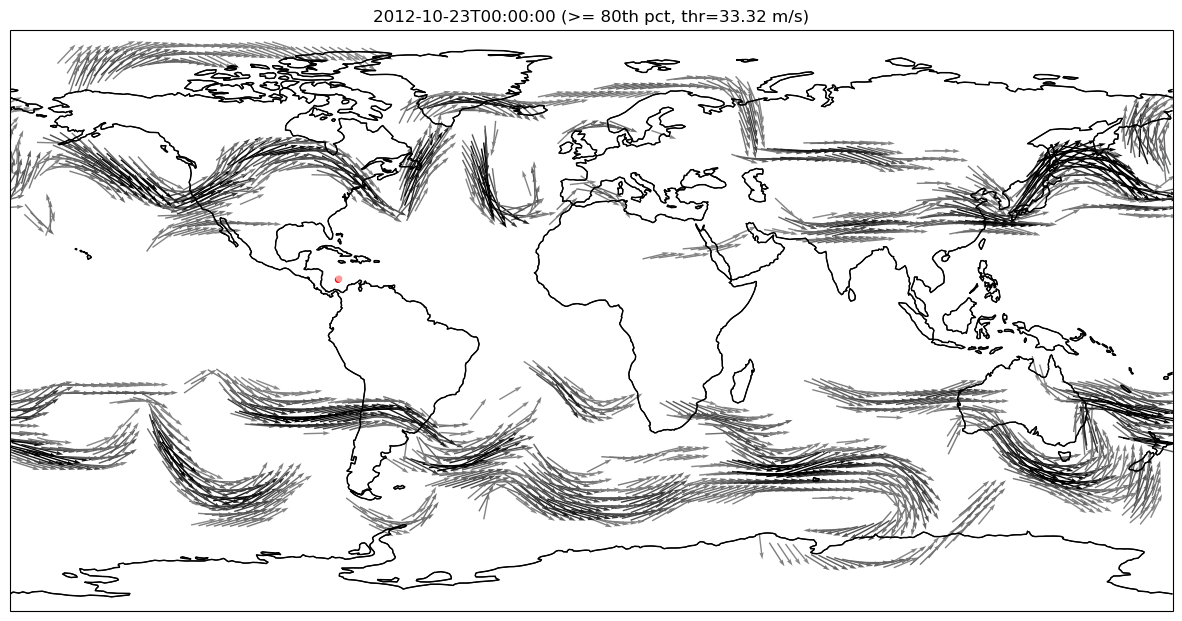

In [365]:
speed = np.hypot(u, v)  # sqrt(u**2 + v**2)

# 50th percentile (median) of speed over finite points
p = 80
thr = np.nanpercentile(speed[np.isfinite(speed)], p)

belowThresholdMask = speed < thr  # mask out below-median speeds
mask = speed > thr

u_masked = np.where(belowThresholdMask, np.nan, u)
v_masked = np.where(belowThresholdMask, np.nan, v)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u_masked, v_masked, lats, lons,
    time=timeStr,
    stride=10,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr} (>= {p}th pct, thr={thr:.2f} m/s)",
)

plt.show()


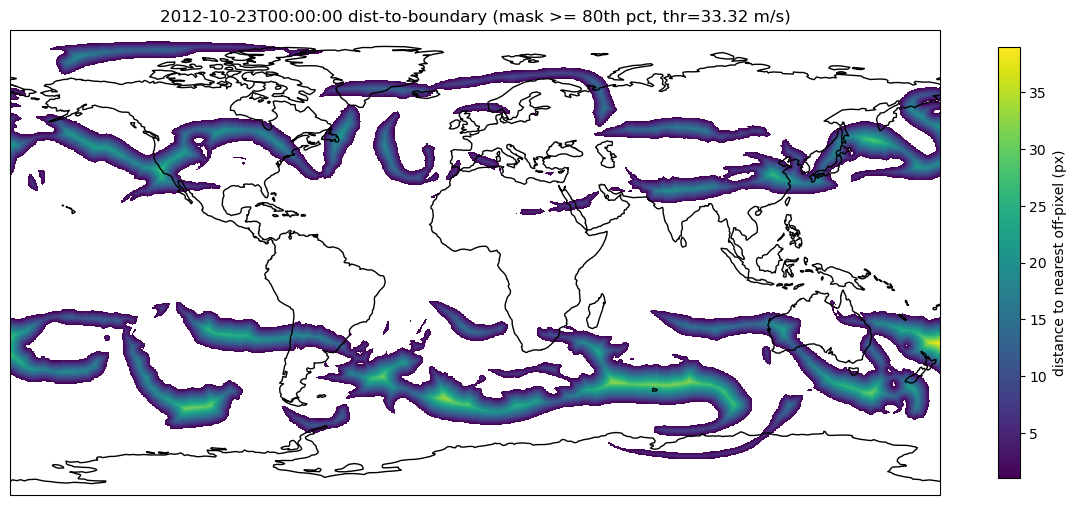

In [366]:
def ensure_lonlat_2d(lats, lons, field2d):
    # field2d is just to infer expected shape
    if np.ndim(lats) == 1 and np.ndim(lons) == 1 and field2d.ndim == 2:
        Lon, Lat = np.meshgrid(lons, lats)
    else:
        Lon = np.asarray(lons)
        Lat = np.asarray(lats)
    return Lon, Lat


dist = ndi.distance_transform_edt(mask)  # pixels

Lon, Lat = ensure_lonlat_2d(lats, lons, dist)

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

# show distance only inside mask; outside is transparent
dist_plot = np.where(mask, dist, np.nan)

im = ax.pcolormesh(Lon, Lat, dist_plot, transform=ccrs.PlateCarree(), shading="auto")
plt.colorbar(im, ax=ax, shrink=0.7, label="distance to nearest off-pixel (px)")

ax.set_title(f"{timeStr} dist-to-boundary (mask >= {p}th pct, thr={thr:.2f} m/s)")
plt.show()


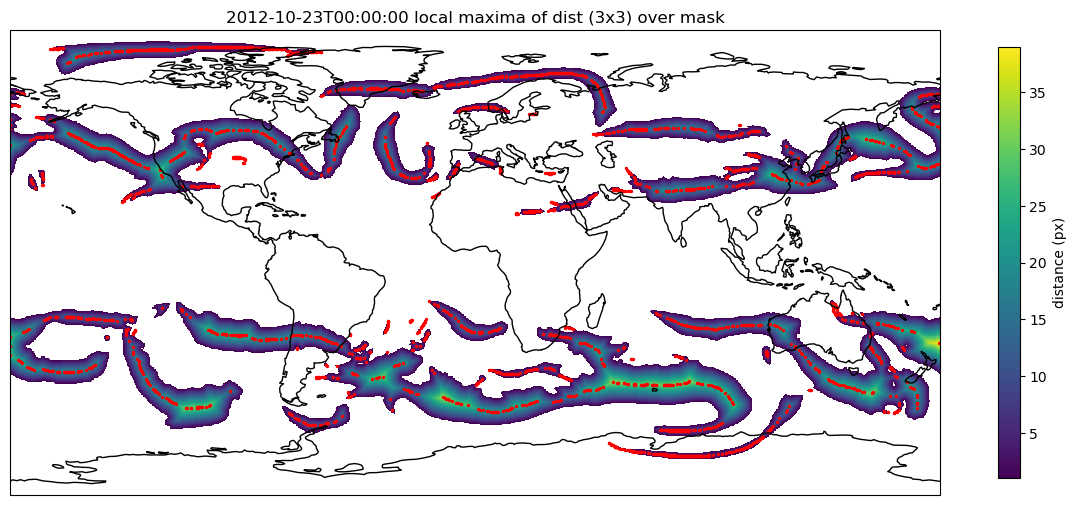

In [367]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.ndimage import maximum_filter

local_max = (dist == maximum_filter(dist, size=3)) & mask

Lon, Lat = ensure_lonlat_2d(lats, lons, dist)

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

dist_plot = np.where(mask, dist, np.nan)
im = ax.pcolormesh(Lon, Lat, dist_plot, transform=ccrs.PlateCarree(), shading="auto")
plt.colorbar(im, ax=ax, shrink=0.7, label="distance (px)")

# overlay the maxima points
yy, xx = np.where(local_max)
ax.scatter(Lon[yy, xx], Lat[yy, xx], s=2, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"{timeStr} local maxima of dist (3x3) over mask")
plt.show()


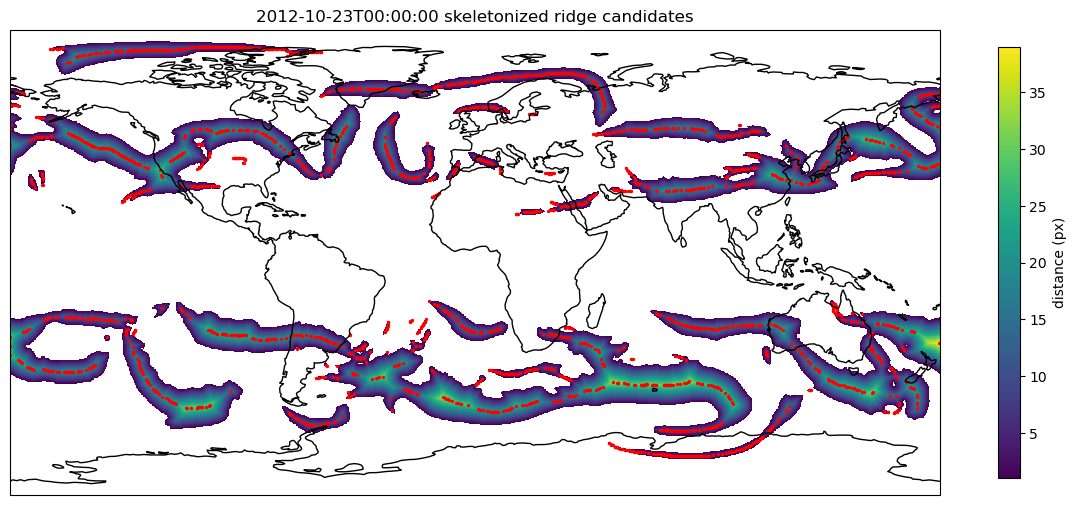

In [368]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from skimage.morphology import skeletonize

ridge_skel = skeletonize(local_max)

Lon, Lat = ensure_lonlat_2d(lats, lons, dist)

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

dist_plot = np.where(mask, dist, np.nan)
im = ax.pcolormesh(Lon, Lat, dist_plot, transform=ccrs.PlateCarree(), shading="auto")
plt.colorbar(im, ax=ax, shrink=0.7, label="distance (px)")

yy, xx = np.where(ridge_skel)
ax.scatter(Lon[yy, xx], Lat[yy, xx], s=2, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"{timeStr} skeletonized ridge candidates")
plt.show()


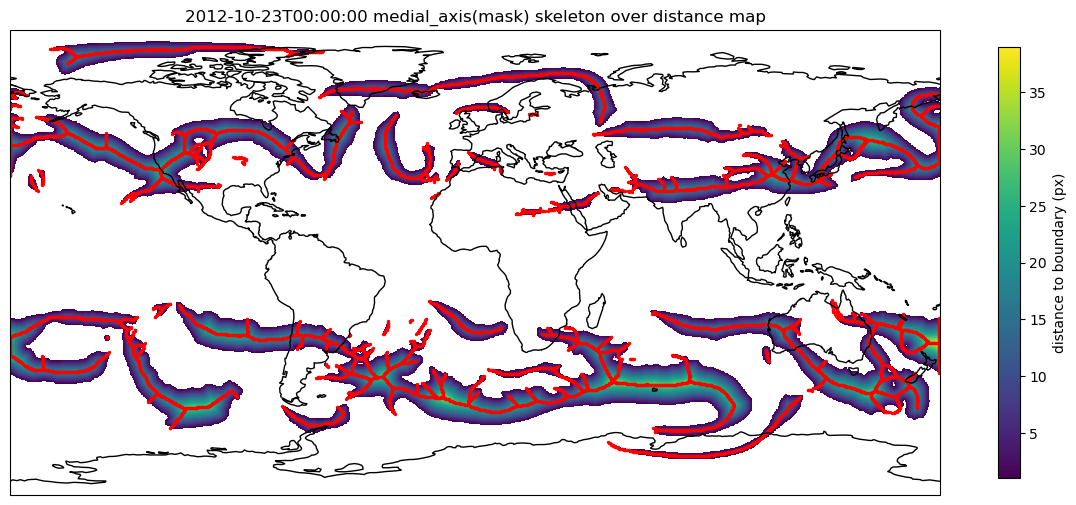

In [369]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from skimage.morphology import medial_axis

ridge_skel2, dist2 = medial_axis(mask, return_distance=True)

Lon, Lat = ensure_lonlat_2d(lats, lons, dist2)

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

dist_plot = np.where(mask, dist2, np.nan)
im = ax.pcolormesh(Lon, Lat, dist_plot, transform=ccrs.PlateCarree(), shading="auto")
plt.colorbar(im, ax=ax, shrink=0.7, label="distance to boundary (px)")

yy, xx = np.where(ridge_skel2)
ax.scatter(Lon[yy, xx], Lat[yy, xx], s=2, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"{timeStr} medial_axis(mask) skeleton over distance map")
plt.show()
